In [23]:
# We import all the needed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.api import ExponentialSmoothing

from busy_airports.preprocessing import load_data, retrieve_airport_data
from busy_airports.metrics import evaluate_forecast
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly
from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing

In [28]:
#Import the data
data =load_data("../data/tsa-throughput-data-complete.csv")


We will work with data from one airport, Chicago O'Hare International Airport.
We want to test some baseline forecasts for the daily passenger throughput in this airport.

In [29]:
#Fix the airport data for Chicago O'Hare for daily frequency
data_ord_d = retrieve_airport_data(data, "ORD", frequency="D") #Fixing Chicago O'Hare data for daily frequency

We first run a simple time-series split with training on 2022,2023 and 2024 data, and keeping 2025 data upto June 23, 2025 as holdout.

Later we will use a cross-validation time-series split for better accuracy.

Let's see a plot of the data first.

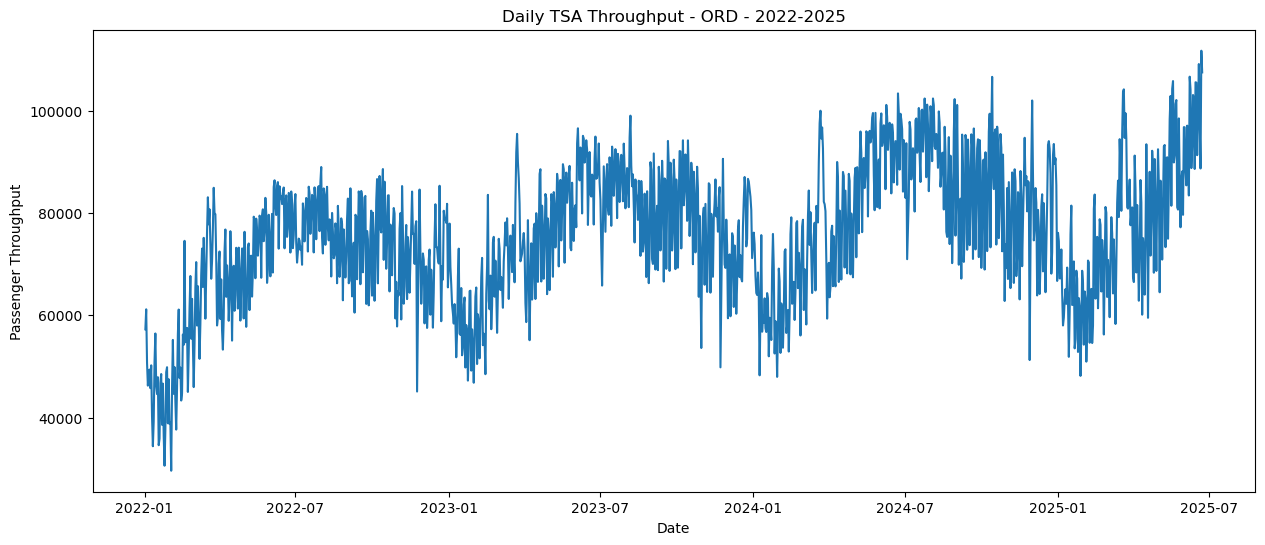

In [32]:

data_ord_d = data_ord_d[data_ord_d['datetime'] < '2025-06-24'] #We only want to use data up to June 24, 2025
plt.figure(figsize=(15, 6))
plt.plot(data_ord_d['datetime'], data_ord_d['total_passenger_throughput'])
plt.title('Daily TSA Throughput - ORD - 2022-2025')
plt.xlabel('Date')
plt.ylabel('Passenger Throughput')
plt.show()

As we can observe there is a clear yearly seasonality to this data, and a mild positive trend as we progress from 2022 to 2025.

We see there is yearly seasonality in the data and also a slight upward trend.
We want to generate some baseline predictions. 

In [33]:
#Selecting the Training Data
data_ord_d_train=data_ord_d[data_ord_d['datetime'] < '2025-01-01']
#Selecting the Holdout Data
data_ord_d_ho=data_ord_d[(data_ord_d['datetime'] > '2024-12-31') & (data_ord_d['datetime'] < '2025-06-24')]

print('Training Data')
print(data_ord_d_train)
print("")
print('Holdout Data')
print(data_ord_d_ho)


Training Data
       datetime  total_passenger_throughput  day
0    2022-01-02                       57237    2
1    2022-01-03                       61147    3
2    2022-01-04                       50709    4
3    2022-01-05                       46234    5
4    2022-01-06                       48520    6
...         ...                         ...  ...
1090 2024-12-27                       93459  362
1091 2024-12-28                       89595  363
1092 2024-12-29                       90659  364
1093 2024-12-30                       85391  365
1094 2024-12-31                       66692  366

[1095 rows x 3 columns]

Holdout Data
       datetime  total_passenger_throughput  day
1095 2025-01-01                       76087    1
1096 2025-01-02                       74477    2
1097 2025-01-03                       67184    3
1098 2025-01-04                       67206    4
1099 2025-01-05                       72844    5
...         ...                         ...  ...
1264 2025-06-19 

We will use two baseline models - a naive seasonal forecast with drift (which was covered in the problem sessions) and triple exponential smoothing.


Time for some predictions!

In [40]:
#Calling nswd
nswd_test = NaiveSeasonalWithDrift(season_length=365)
nswd_test.fit(data_ord_d_train['total_passenger_throughput'])
nswd_forecast=nswd_test.forecast(174)
evaluate_forecast(data_ord_d_ho['total_passenger_throughput'].values, nswd_forecast,
                  model_name="Naive Seasonal With Drift | 2022-2024 Train | H1 2025 Holdout") #error evaluation


{'mae': 11680.954022988506,
 'mape': 0.14803007569770305,
 'rmse': np.float64(14072.55002747768)}

In [42]:
#Calling Exponential Smoothing
es=TripleExponentialSmoothing(season_length=365)
es.fit(data_ord_d_train['total_passenger_throughput'])
es_forecast = es.forecast(174)  
evaluate_forecast(data_ord_d_ho['total_passenger_throughput'].values, es_forecast,
                  model_name="Triple Exponential Smoothing | 2022-2024 Train | H1 2025 Holdout") #error evaluation


{'mae': 9134.045363490011,
 'mape': 0.12470490842774033,
 'rmse': np.float64(11467.652564378832)}

Let's plot how the two baseline models fared with the holdout data.

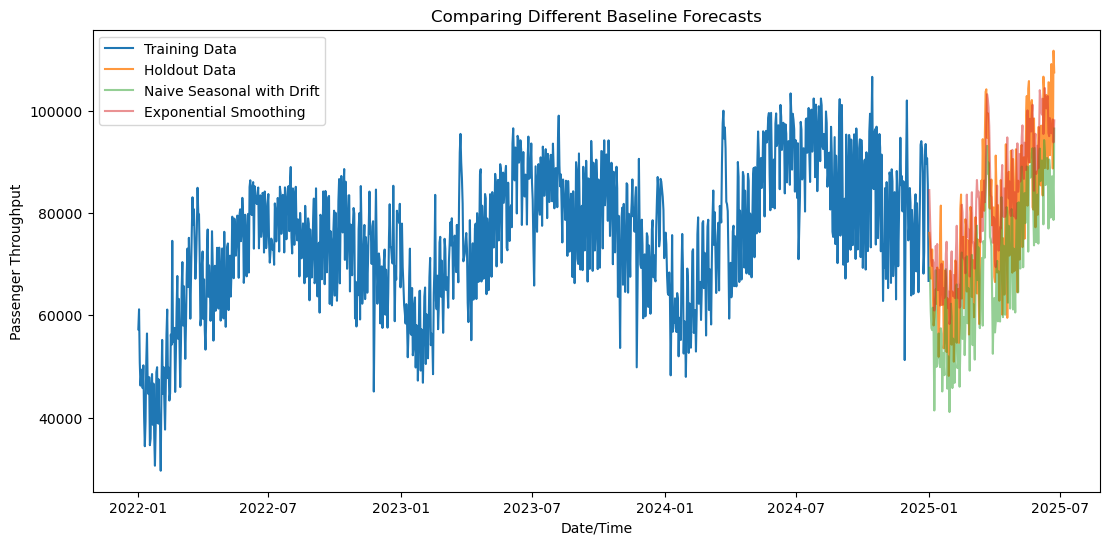

In [46]:
#Plotting the data
plt.figure(figsize=(13, 6))
plt.plot(data_ord_d_train["datetime"],data_ord_d_train["total_passenger_throughput"].values, label='Training Data')
plt.plot(data_ord_d_ho["datetime"],data_ord_d_ho["total_passenger_throughput"].values, label='Holdout Data', alpha=0.8)
plt.plot(data_ord_d_ho["datetime"],nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.plot(data_ord_d_ho["datetime"],es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.title('Comparing Different Baseline Forecasts')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

We can zoom into the section with just the 2024 data to better visualize how close the predictions were.

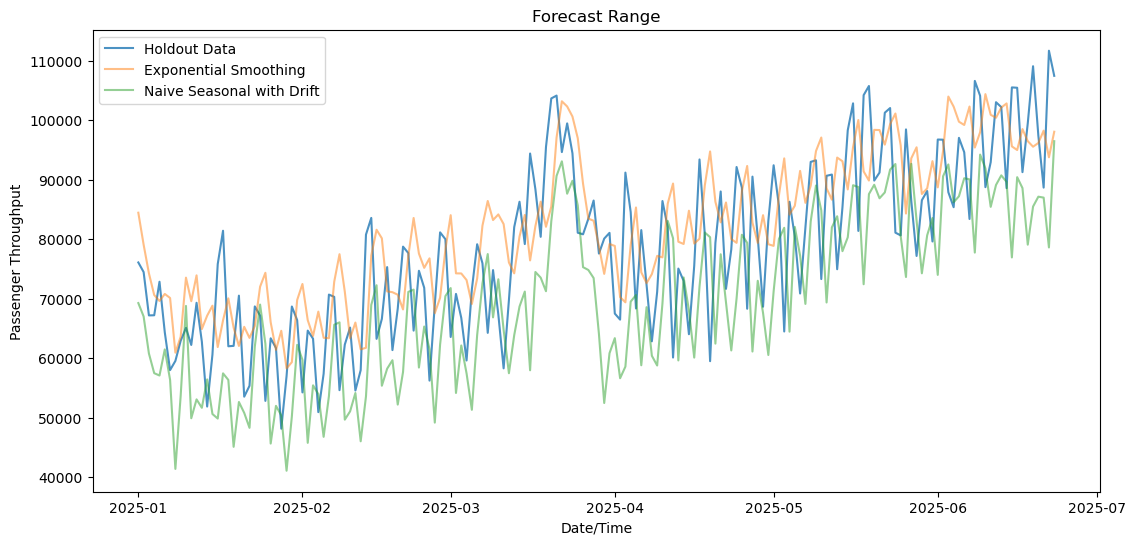

In [50]:
#Let's visualize only the holdout data and exp smoothing
plt.figure(figsize=(13, 6))
plt.plot(data_ord_d_ho["datetime"],data_ord_d_ho["total_passenger_throughput"].values, label='Holdout Data',alpha=0.8)
plt.plot(data_ord_d_ho["datetime"],es_forecast, label="Exponential Smoothing",alpha=0.5)
plt.plot(data_ord_d_ho["datetime"]  ,nswd_forecast, label="Naive Seasonal with Drift",alpha=0.5)
plt.title('Forecast Range')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

Let's run a cross-validated split now, with training by rolling splits. We have a baseline of 2022,2023 and an additional 90 days at each fold. We make five folds. The final date is June 24,2025.

In [52]:
splits = make_rolling_splits(data_ord_d, date_col='datetime', n_splits=5, step_days=90)



Split 1: train → 2024-03-30 | test 2024-03-31 → 2024-06-28 (90 days)
Split 2: train → 2024-06-28 | test 2024-06-29 → 2024-09-26 (90 days)
Split 3: train → 2024-09-26 | test 2024-09-27 → 2024-12-25 (90 days)
Split 4: train → 2024-12-25 | test 2024-12-26 → 2025-03-25 (90 days)
Split 5: train → 2025-03-25 | test 2025-03-26 → 2025-06-23 (90 days)


Lets run the baseline models on these splits now.

In [63]:
#For NSWD
results = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = data_ord_d.iloc[train_idx]['total_passenger_throughput']
    test  = data_ord_d.iloc[test_idx]['total_passenger_throughput']

    model = NaiveSeasonalWithDrift(season_length=365)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

# Summary across all splits
results_df = pd.DataFrame(results).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_df['mae'].mean():,.0f}")
print(f"  MAPE: {100*results_df['mape'].mean():.2f}%")
print(f"  RMSE: {results_df['rmse'].mean():,.0f}")

Split 1 - MAE: 20708, MAPE: 23.64%, RMSE: 22981
Split 2 - MAE: 9248, MAPE: 10.88%, RMSE: 11511
Split 3 - MAE: 14555, MAPE: 19.38%, RMSE: 17957
Split 4 - MAE: 16882, MAPE: 23.29%, RMSE: 19221
Split 5 - MAE: 14919, MAPE: 16.93%, RMSE: 17854

CV Average:
  MAE:  15,263
  MAPE: 18.82%
  RMSE: 17,905


In [64]:
#For Exp. smoothing
results_tes = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = ord_daily.iloc[train_idx]['Total Passenger Throughput']
    test  = ord_daily.iloc[test_idx]['Total Passenger Throughput']

    model = TripleExponentialSmoothing(season_length=365)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted.values, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_tes.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")


results_tes_df = pd.DataFrame(results_tes).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_tes_df['mae'].mean():,.0f}")
print(f"  MAPE: {100*results_tes_df['mape'].mean():.2f}%")
print(f"  RMSE: {results_tes_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8707, MAPE: 10.58%, RMSE: 10327
Split 2 - MAE: 9773, MAPE: 11.53%, RMSE: 11507
Split 3 - MAE: 10581, MAPE: 13.66%, RMSE: 12703
Split 4 - MAE: 8733, MAPE: 13.18%, RMSE: 10659
Split 5 - MAE: 9556, MAPE: 11.55%, RMSE: 11728

CV Average:
  MAE:  9,470
  MAPE: 12.10%
  RMSE: 11,385


Exponential Smooting is doing much better here.

/usr/local/Caskroom/miniconda/base/envs/busy_airports/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


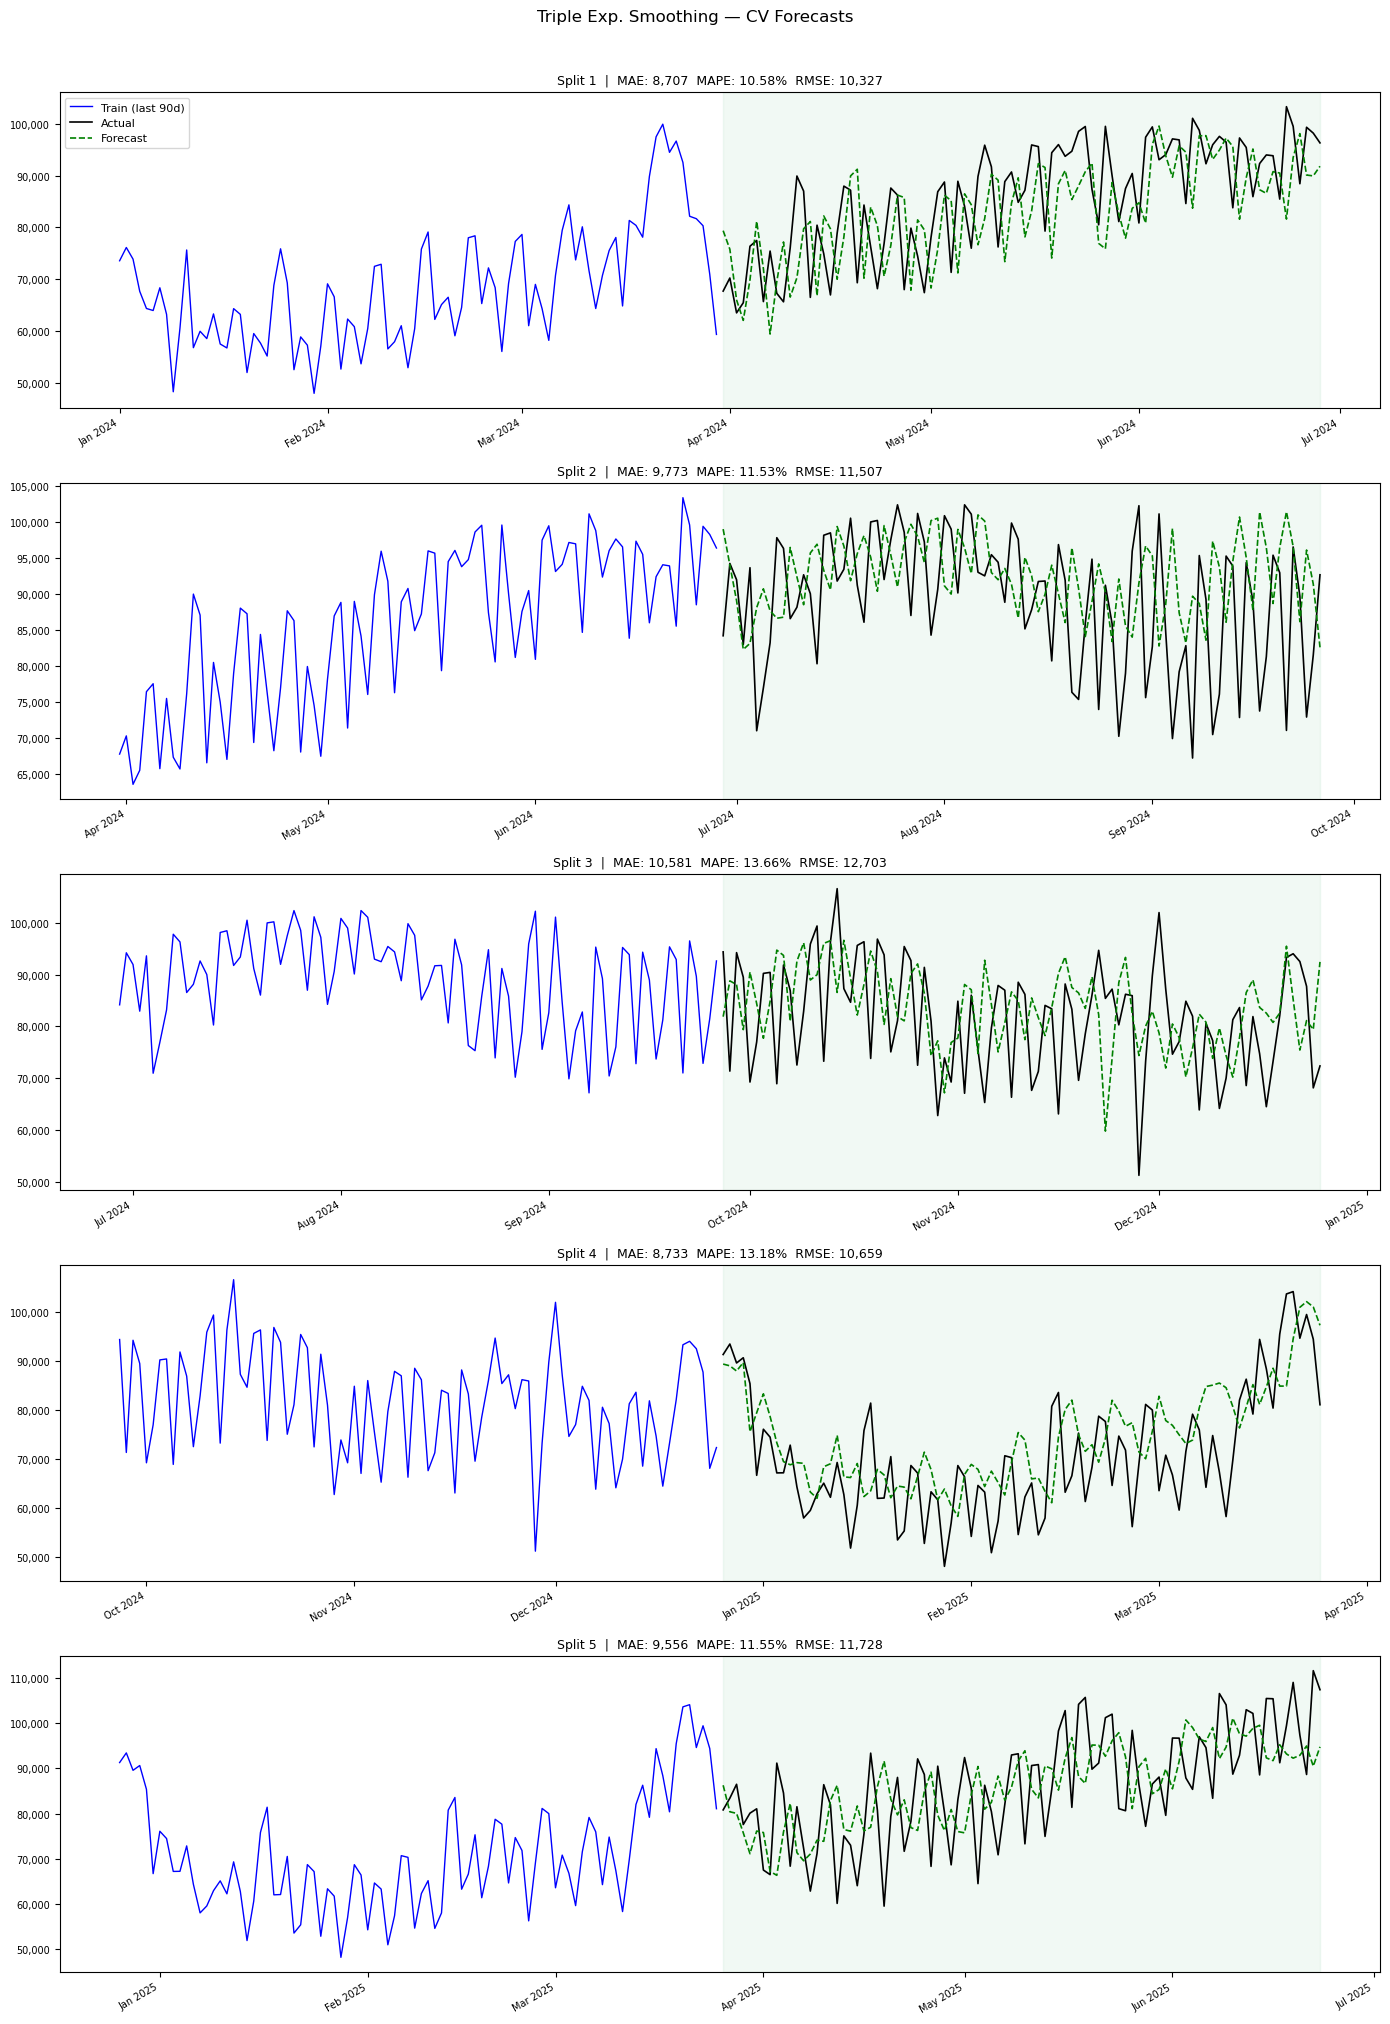

In [67]:
#Plot for Exponential Smoothing
from matplotlib import dates as mdates
fig, axes = plt.subplots(5, 1, figsize=(14, 20))
fig.suptitle('Triple Exp. Smoothing — CV Forecasts', y=1.01)

for i, (train_idx, test_idx) in enumerate(splits):
    ax = axes[i]

    train_dates = data_ord_d.iloc[train_idx]['datetime']
    test_dates  = data_ord_d.iloc[test_idx]['datetime']
    train_vals  = data_ord_d.iloc[train_idx]['total_passenger_throughput']
    test_vals   = data_ord_d.iloc[test_idx]['total_passenger_throughput']

    model = TripleExponentialSmoothing(season_length=365)
    model.fit(train_vals)
    predicted = model.forecast(h=len(test_vals)).values

    train_plot_dates = train_dates.iloc[-90:]
    train_plot_vals  = train_vals.iloc[-90:]

    ax.plot(train_plot_dates, train_plot_vals,
            color='blue', linewidth=1, label='Train (last 90d)')
    ax.plot(test_dates, test_vals,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_dates, predicted,
            color='green', linewidth=1.2, linestyle='--', label='Forecast')

    ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1], alpha=0.07, color='mediumseagreen')

    row = results_tes_df.loc[i + 1]
    ax.set_title(
        f'Split {i+1}  |  MAE: {row["mae"]:,.0f}  MAPE: {100*row["mape"]:.2f}%  RMSE: {row["rmse"]:,.0f}',
        fontsize=9
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

Let's see how the weekly data behaves.

In [68]:
#Import and process weekly data for Chicago airport
data_ord_w = retrieve_airport_data(data, "ORD", frequency="W")

 We cross-validate as before, with a baseline of 2022,2023 and an additional 13 weeks at each fold. The final date is June 29,2025.

In [69]:
ord_weekly= data_ord_w[data_ord_w.index <= 181]
splits = make_rolling_splits_weekly(ord_weekly, date_col='datetime', n_splits=5, step_weeks=13)

Split 1: train → row 116 (2024-03-31) | test rows 117–129 (2024-04-07 → 2024-06-30) (13 weeks)
Split 2: train → row 129 (2024-06-30) | test rows 130–142 (2024-07-07 → 2024-09-29) (13 weeks)
Split 3: train → row 142 (2024-09-29) | test rows 143–155 (2024-10-06 → 2024-12-29) (13 weeks)
Split 4: train → row 155 (2024-12-29) | test rows 156–168 (2025-01-05 → 2025-03-30) (13 weeks)
Split 5: train → row 168 (2025-03-30) | test rows 169–181 (2025-04-06 → 2025-06-29) (13 weeks)


In [74]:
#For NSWD
results = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = ord_weekly.iloc[train_idx]['total_passenger_throughput']
    test  = ord_weekly.iloc[test_idx]['total_passenger_throughput']

    model = NaiveSeasonalWithDrift(season_length=52)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

# Summary across all splits
results_df = pd.DataFrame(results).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_df['rmse'].mean():,.0f}")

Split 1 - MAE: 24071, MAPE: 3.90%, RMSE: 28144
Split 2 - MAE: 14224, MAPE: 2.28%, RMSE: 15503
Split 3 - MAE: 21894, MAPE: 3.79%, RMSE: 25913
Split 4 - MAE: 16755, MAPE: 3.56%, RMSE: 20865
Split 5 - MAE: 41694, MAPE: 7.08%, RMSE: 48477

CV Average:
  MAE:  23,728
  MAPE: 4.12%
  RMSE: 27,781


In [76]:
#For Exp. smoothing
results_tes = []

for i, (train_idx, test_idx) in enumerate(splits):
    train = ord_weekly.iloc[train_idx]['total_passenger_throughput']
    test  = ord_weekly.iloc[test_idx]['total_passenger_throughput']

    model = TripleExponentialSmoothing(season_length=52)
    model.fit(train)
    predicted = model.forecast(h=len(test))

    metrics = evaluate_forecast(test.values, predicted.values, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_tes.append(metrics)
    print(f"Split {i+1} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_tes_df = pd.DataFrame(results_tes).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_tes_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_tes_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_tes_df['rmse'].mean():,.0f}")

Split 1 - MAE: 10010, MAPE: 1.66%, RMSE: 13273
Split 2 - MAE: 16351, MAPE: 2.60%, RMSE: 18889
Split 3 - MAE: 26545, MAPE: 4.69%, RMSE: 29981
Split 4 - MAE: 25652, MAPE: 5.47%, RMSE: 30133
Split 5 - MAE: 26140, MAPE: 4.53%, RMSE: 32891

CV Average:
  MAE:  20,940
  MAPE: 3.79%
  RMSE: 25,033


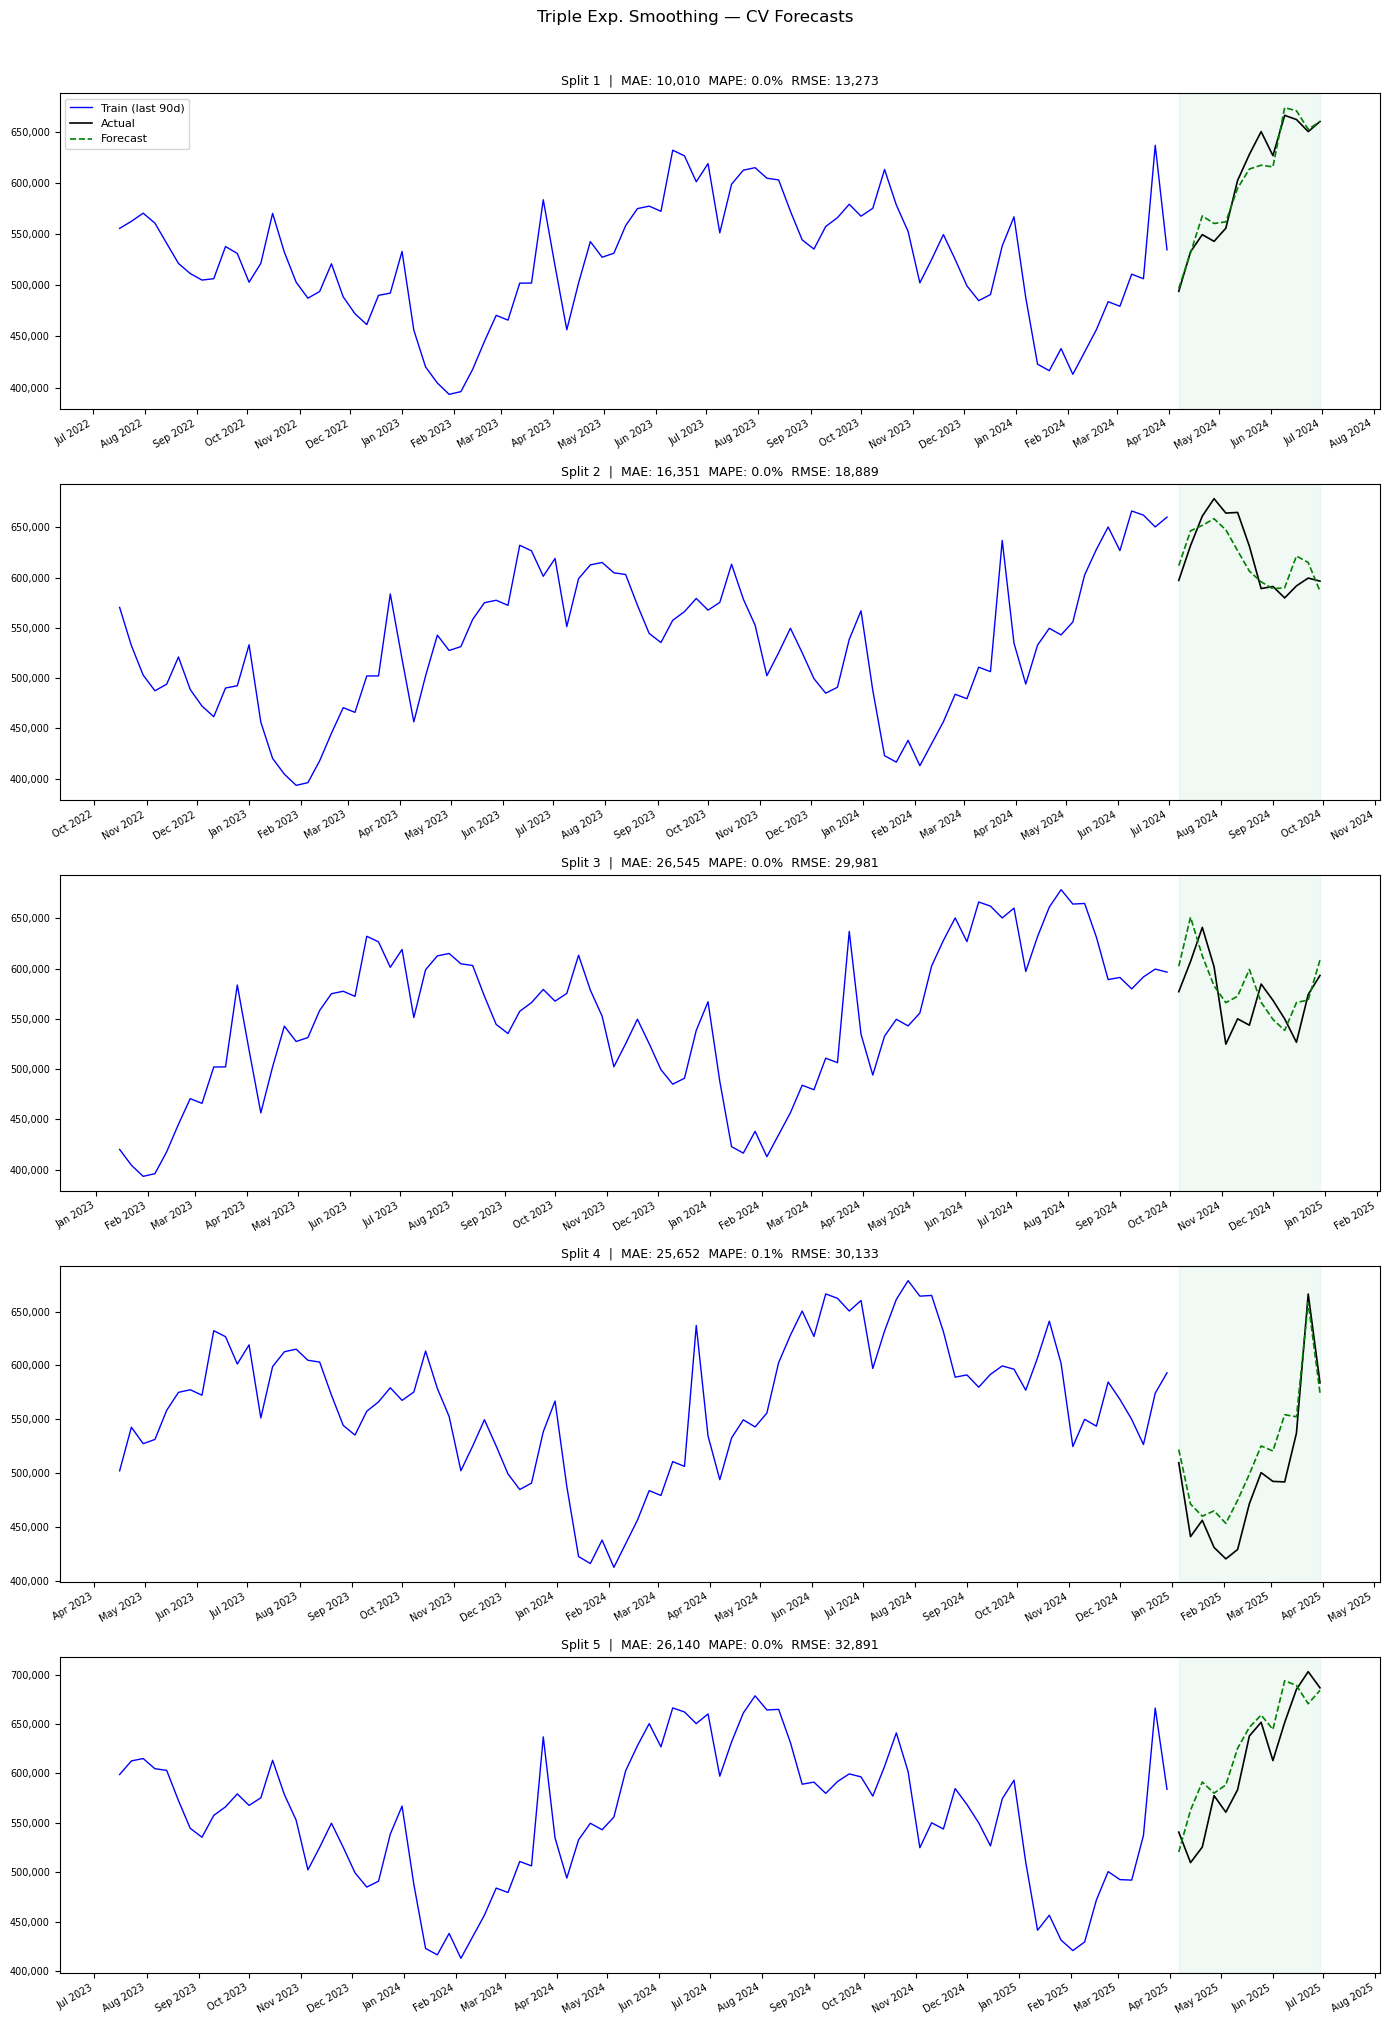

In [75]:
#Plot for Exponential Smoothing
from matplotlib import dates as mdates
fig, axes = plt.subplots(5, 1, figsize=(14, 20))
fig.suptitle('Triple Exp. Smoothing — CV Forecasts', y=1.01)

for i, (train_idx, test_idx) in enumerate(splits):
    ax = axes[i]

    train_dates = ord_weekly.iloc[train_idx]['datetime']
    test_dates  = ord_weekly.iloc[test_idx]['datetime']
    train_vals  = ord_weekly.iloc[train_idx]['total_passenger_throughput']
    test_vals   = ord_weekly.iloc[test_idx]['total_passenger_throughput']

    model = TripleExponentialSmoothing(season_length=52)
    model.fit(train_vals)
    predicted = model.forecast(h=len(test_vals)).values

    train_plot_dates = train_dates.iloc[-90:]
    train_plot_vals  = train_vals.iloc[-90:]

    ax.plot(train_plot_dates, train_plot_vals,
            color='blue', linewidth=1, label='Train (last 90d)')
    ax.plot(test_dates, test_vals,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_dates, predicted,
            color='green', linewidth=1.2, linestyle='--', label='Forecast')

    ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1], alpha=0.07, color='mediumseagreen')

    row = results_tes_df.loc[i + 1]
    ax.set_title(
        f'Split {i+1}  |  MAE: {row["mae"]:,.0f}  MAPE: {row["mape"]:.1f}%  RMSE: {row["rmse"]:,.0f}',
        fontsize=9
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='y', labelsize=7)

    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()